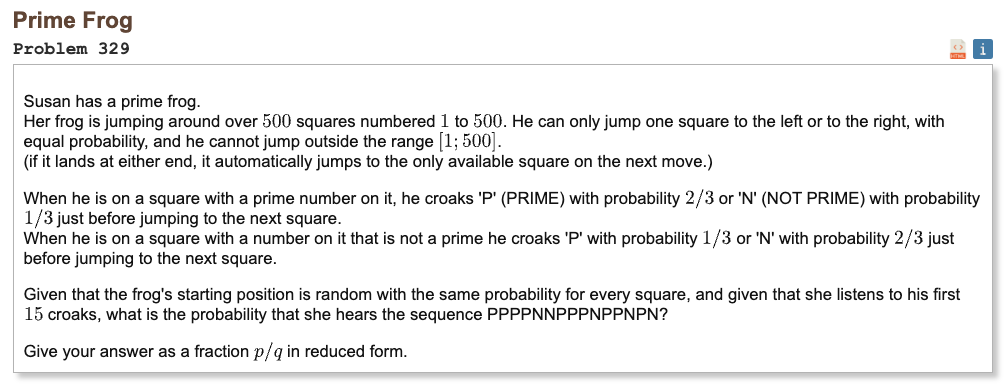

## Initial approach

* keep an exact fraction probability for every square
* start with the frog equally likely to be on any square
* for each croak, multiply each square by the correct croak probability
* after hearing a croak, move the probability mass left and right
* endpoints only move inward because the frog cannot jump outside
* after processing all croaks, sum the remaining probabilities
* use Fraction so the final answer is already exact and reduced

In [1]:
from fractions import Fraction
import math

def prime_sieve(limit):
    is_prime = [True] * (limit + 1)
    is_prime[0] = False
    is_prime[1] = False

    for p in range(2, math.isqrt(limit) + 1):
        if is_prime[p]:
            for multiple in range(p * p, limit + 1, p):
                is_prime[multiple] = False

    return is_prime

def croak_probability(square, sound, is_prime):
    if is_prime[square]:
        return Fraction(2, 3) if sound == "P" else Fraction(1, 3)

    return Fraction(1, 3) if sound == "P" else Fraction(2, 3)

def solve():
    limit = 500
    sounds = "PPPPNNPPPNPPNPN"
    is_prime = prime_sieve(limit)

    probabilities = [Fraction(0, 1)] * (limit + 1)

    for square in range(1, limit + 1):
        probabilities[square] = Fraction(1, limit)

    for step, sound in enumerate(sounds):
        for square in range(1, limit + 1):
            probabilities[square] *= croak_probability(square, sound, is_prime)

        if step == len(sounds) - 1:
            break

        next_probabilities = [Fraction(0, 1)] * (limit + 1)

        for square in range(1, limit + 1):
            if square == 1:
                next_probabilities[2] += probabilities[square]
            elif square == limit:
                next_probabilities[limit - 1] += probabilities[square]
            else:
                next_probabilities[square - 1] += probabilities[square] * Fraction(1, 2)
                next_probabilities[square + 1] += probabilities[square] * Fraction(1, 2)

        probabilities = next_probabilities

    return sum(probabilities)

In [2]:
%%time
result = solve()
print("Result:", f"{result.numerator}/{result.denominator}")

Result: 199740353/29386561536000
CPU times: user 31 ms, sys: 1.63 ms, total: 32.6 ms
Wall time: 31.6 ms
